# Module 3b — open temporal instrument: `R_δ(N, γ_φ t)` curves

Reproducible example for `tmc_numerics.modules.open_instrument`. Regenerates the committed result `results/open_instrument_redundancy_v0.1.json` from scratch. The candidate worked exemplar for **Anti-Claim #6**, within the assumed-einselection regime.

> **Einselection caveat (verbatim).** Module 3b computes `R_δ(N, γ_φ, t)` *conditional on the assumption that the temporal pointer `T` is einselected* (MN v0.2 §1.1). The existence of a dynamically-derived temporal-pointer basis — the temporal analogue of environment-induced superselection — is the hardest part of the Coastline's principal open problem (**Anti-Claim #6**) and is **not** addressed here: it is *assumed*, not derived. Module 3b is therefore a **candidate** worked exemplar of a *redundant temporal record* **within the assumed regime**, not a resolution of Anti-Claim #6, which **remains open**. Whether any such instance counts as *the* worked exemplar that converts Coastline Claim II from analogy to demonstration is a Coastline-level judgement reserved to the steward (Lock-Key).

In [1]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
import tmc_numerics as tn
from tmc_numerics.modules.open_instrument import (
    OpenInstrumentParams, single_carrier_coherence, carrier_distinguishability,
    redundancy_at, redundancy_curve)
print('tmc_numerics', tn.__version__)

tmc_numerics 0.1.0.dev0


## 1. Derive `ε` from a single-carrier dephasing master equation

`c = 2|ρ₀₁|` of `|+⟩` evolved under `(γ_φ/2)D[σ_z]` (Phase-1 `evolve`) `= e^{−γ_φ t}`; then `ε = (1−c)/2` (trace-distance / Helstrom / phase-bin projective — all coincide).

In [2]:
gamma_phi = 1.0
for t in [0.0, 0.25, np.log(5/3), 1.0, 2.0]:
    c = single_carrier_coherence(gamma_phi, t)
    eps = carrier_distinguishability(gamma_phi, t)
    print(f'gamma_phi*t={t:<7.4f} c={c:.4f}  eps=(1-c)/2={eps:.4f}  [analytic {(1-np.exp(-t))/2:.4f}]')

gamma_phi*t=0.0000  c=1.0000  eps=(1-c)/2=0.0000  [analytic 0.0000]
gamma_phi*t=0.2500  c=0.7788  eps=(1-c)/2=0.1106  [analytic 0.1106]
gamma_phi*t=0.5108  c=0.6000  eps=(1-c)/2=0.2000  [analytic 0.2000]
gamma_phi*t=1.0000  c=0.3679  eps=(1-c)/2=0.3161  [analytic 0.3161]
gamma_phi*t=2.0000  c=0.1353  eps=(1-c)/2=0.4323  [analytic 0.4323]


## 2. D5 cross-link — the dynamical path lands on the MN §2 analytic pole

At `γ_φ t = ln(5/3)` (`ε=0.20`), `R_{0.10}(N=64)` must equal `64/9` exactly.

In [3]:
t_star = np.log(5/3)
r = redundancy_at(OpenInstrumentParams(gamma_phi, t_star, 64, 0.10))
print(f'gamma_phi*t = ln(5/3) = {t_star:.4f}  ->  eps = 0.20')
print(f'R_0.10(N=64) = {r.R_delta:.6f}  (64/9 = {64/9:.6f}),  m_delta = {r.m_delta}')
assert abs(r.R_delta - 64/9) < 1e-9 and r.m_delta == 9
print('OK - dynamical path reproduces the analytic pole to the D5 standard')

gamma_phi*t = ln(5/3) = 0.5108  ->  eps = 0.20
R_0.10(N=64) = 7.111111  (64/9 = 7.111111),  m_delta = 9
OK - dynamical path reproduces the analytic pole to the D5 standard


## 3. `R_δ(N, γ_φ t)` curves

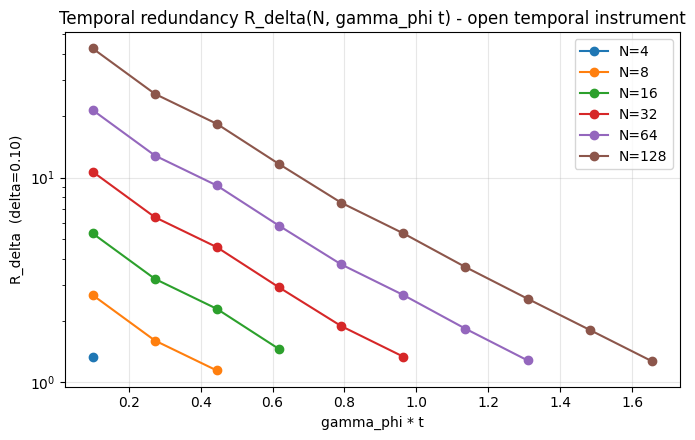

In [4]:
n_values = [4, 8, 16, 32, 64, 128]
t_values = [round(x, 3) for x in np.linspace(0.1, 2.0, 12)]
cur = redundancy_curve(gamma_phi=gamma_phi, t_values=t_values, n_values=n_values, deficit=0.10)
plt.figure(figsize=(7, 4.5))
for n in n_values:
    pts = [(row[0], row[2]) for row in cur['grid'][n] if row[2] is not None]
    if pts:
        xs, ys = zip(*pts)
        plt.plot(xs, ys, 'o-', label=f'N={n}')
plt.xlabel('gamma_phi * t'); plt.ylabel('R_delta  (delta=0.10)'); plt.yscale('log')
plt.title('Temporal redundancy R_delta(N, gamma_phi t) - open temporal instrument')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 4. The undefined boundary rises with N

`R_δ` is *undefined* once even the full set fails `I(N) ≥ (1−δ)H_T` (`ε ≥ ε_crit(N,δ)`). `ε_crit` rises with N — more independent carriers tolerate more per-carrier nuisance (MN §5).

In [5]:
for n in n_values:
    print(f'  N={n:<5} first gamma_phi*t with R_delta undefined: {cur["undefined_boundary"][n]}')
boundary = [cur['undefined_boundary'][n] for n in n_values]
assert all(a <= b for a, b in zip(boundary, boundary[1:]))  # rises (weakly) with N
print('\n-> a redundant temporal record destroyed by per-carrier nuisance alone, no entanglement change.')

  N=4     first gamma_phi*t with R_delta undefined: 0.273
  N=8     first gamma_phi*t with R_delta undefined: 0.618
  N=16    first gamma_phi*t with R_delta undefined: 0.791
  N=32    first gamma_phi*t with R_delta undefined: 1.136
  N=64    first gamma_phi*t with R_delta undefined: 1.482
  N=128   first gamma_phi*t with R_delta undefined: 1.827

-> a redundant temporal record destroyed by per-carrier nuisance alone, no entanglement change.


## 5. Matches the committed artifact

In [6]:
with open('../results/open_instrument_redundancy_v0.1.json') as f:
    committed = json.load(f)
assert committed['undefined_boundary']['64'] == cur['undefined_boundary'][64]
print('OK - notebook regenerates the committed R_delta grid + boundary')

OK - notebook regenerates the committed R_delta grid + boundary
